# Phase 13 (Bonus) — Multistream và Cross-stream Knowledge Transfer

**Kịch bản mô phỏng (không có trong dữ liệu gốc):** một "đội máy" 3 máy chịu cùng một thay đổi môi trường (RPM −150, Torque +8), nhưng thay đổi đến **lệch thời điểm** giữa các máy. Mỗi máy có FIS, ADWIN và buffer riêng. Knowledge base dùng chung chỉ lưu **vector độ dịch MF không nhãn** của máy thích nghi xong đầu tiên. Không máy nào dùng nhãn của máy khác.

Chế độ:
- `independent`: mỗi máy tự làm như Phase 7 (phát hiện → buffer 200 → thích nghi).
- `transfer`: khi máy tự phát hiện drift, **áp dụng ngay** vector của máy khác (nếu đã có), rồi vẫn thu buffer riêng để tinh chỉnh phần dư.
- `transfer_only`: chỉ áp dụng vector được chuyển, không tinh chỉnh (ablation).

**Lưu ý về dữ liệu:** Test (UDI 8001–10000) chỉ đủ cho một luồng 2.000 mẫu. Máy B dùng UDI 6001–8000 (Validation) và máy C dùng UDI 4001–6000 (thuộc Train). Hai đoạn này đã được nhìn thấy khi thiết kế MF và ngưỡng, nên **F1/FPR tuyệt đối của B và C lạc quan**. Chỉ nên so sánh **các chế độ với nhau trên cùng một máy**. Riêng C chứa toàn bộ lỗi HDF của dataset nên số ca lỗi rất khác A và B.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent; sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src.data import load_dataset, inject_sudden
from src.multistream import MultiStreamMonitor
from src.evaluation import evaluate
df = load_dataset()
BASES = {"A": df.iloc[8000:10000].reset_index(drop=True), "B": df.iloc[6000:8000].reset_index(drop=True), "C": df.iloc[4000:6000].reset_index(drop=True)}
for k, b in BASES.items(): print(k, "UDI", b.UDI.iloc[0], "→", b.UDI.iloc[-1], "| failures =", int(b["Machine failure"].sum()))

def fleet(onsets, torque_only=()):
    out = {}
    for k, b in BASES.items():
        rpm = 0 if k in torque_only else -150
        out[k] = inject_sudden(b, point=onsets[k], rpm_shift=rpm, torque_shift=8)
    return out

def evaluate_fleet(streams, onsets, label):
    rows, logs_all = [], {}
    for mode in ["independent", "transfer", "transfer_only"]:
        m = MultiStreamMonitor(streams, mode=mode); logs = m.run(); logs_all[mode] = (m, logs)
        for k, st in m.states.items():
            ev = {e["event"]: e["t"] for e in st.events}
            first_adapt = min([e["t"] for e in st.events if e["event"] in ("adapted", "transferred")], default=None)
            log = logs[k]; e = evaluate(log.label, log.score); post = log.iloc[onsets[k]:]
            ep = evaluate(post.label, post.score)
            rows.append({"scenario": label, "mode": mode, "machine": k, "onset": onsets[k], "detected": ev.get("drift_detected"),
                         "first adaptation": first_adapt, "onset→first adapt": (first_adapt - onsets[k]) if first_adapt else None,
                         "events": ", ".join(f"{e['event']}@{e['t']}" for e in st.events if e["event"] != "drift_detected"),
                         "FP after onset": ep["FP"], "TP after onset": ep["TP"], "F1": round(e["F1"], 4), "FPR": round(e["FPR"], 4),
                         "KB source": m.knowledge_source[0] if m.knowledge_source else None})
    return pd.DataFrame(rows), logs_all

A UDI 8001 → 10000 | failures = 39
B UDI 6001 → 8000 | failures = 45
C UDI 4001 → 6000 | failures = 154


## 13.1 — Cùng drift, onset lệch nhau đủ xa (A: 800, B: 1100, C: 1400)

In [2]:
ON1 = {"A": 800, "B": 1100, "C": 1400}
res1, logs1 = evaluate_fleet(fleet(ON1), ON1, "same drift, staggered")
pd.set_option("display.width", 250); pd.set_option("display.max_colwidth", 80)
res1

,scenario,mode,machine,onset,detected,first adaptation,onset→first adapt,events,FP after onset,TP after onset,F1,FPR,KB source
0,"same drift, staggered",independent,A,800,927,1127,327,adapted@1127,38,14,0.2857,0.0291,A
1,"same drift, staggered",independent,B,1100,1183,1383,283,adapted@1383,56,7,0.1778,0.0399,A
2,"same drift, staggered",independent,C,1400,1503,1703,303,adapted@1703,113,9,0.3597,0.0796,A
3,"same drift, staggered",transfer,A,800,927,1127,327,adapted@1127,38,14,0.2857,0.0291,A
4,"same drift, staggered",transfer,B,1100,1183,1183,83,"transferred@1183, refined@1383",46,7,0.1920,0.0348,A
5,"same drift, staggered",transfer,C,1400,1503,1503,103,"transferred@1503, refined@1703",59,8,0.4167,0.0504,A
6,"same drift, staggered",transfer_only,A,800,927,1127,327,adapted@1127,38,14,0.2857,0.0291,A
7,"same drift, staggered",transfer_only,B,1100,1183,1183,83,transferred@1183,65,10,0.2041,0.0445,A
8,"same drift, staggered",transfer_only,C,1400,1503,1503,103,transferred@1503,68,9,0.4099,0.0553,A


## 13.2 — Onset quá sát nhau (A: 1000, B: 1100, C: 1200)

Nếu một máy phát hiện drift *trước khi* máy nguồn thích nghi xong thì chưa có tri thức để chuyển, và chế độ transfer tự rơi về independent.

In [3]:
ON2 = {"A": 1000, "B": 1100, "C": 1200}
res2, _ = evaluate_fleet(fleet(ON2), ON2, "same drift, close onsets")
res2

,scenario,mode,machine,onset,detected,first adaptation,onset→first adapt,events,FP after onset,TP after onset,F1,FPR,KB source
0,"same drift, close onsets",independent,A,1000,1183,1383,383,adapted@1383,34,12,0.2727,0.0286,A
1,"same drift, close onsets",independent,B,1100,1183,1383,283,adapted@1383,56,7,0.1778,0.0399,A
2,"same drift, close onsets",independent,C,1200,1279,1479,279,adapted@1479,123,11,0.3616,0.0785,A
3,"same drift, close onsets",transfer,A,1000,1183,1383,383,adapted@1383,34,12,0.2727,0.0286,A
4,"same drift, close onsets",transfer,B,1100,1183,1383,283,adapted@1383,56,7,0.1778,0.0399,A
5,"same drift, close onsets",transfer,C,1200,1279,1479,279,adapted@1479,123,11,0.3616,0.0785,A
6,"same drift, close onsets",transfer_only,A,1000,1183,1383,383,adapted@1383,34,12,0.2727,0.0286,A
7,"same drift, close onsets",transfer_only,B,1100,1183,1383,283,adapted@1383,56,7,0.1778,0.0399,A
8,"same drift, close onsets",transfer_only,C,1200,1279,1479,279,adapted@1479,123,11,0.3616,0.0785,A


## 13.3 — Negative transfer: máy C chỉ có drift Torque (+8 Nm), RPM không đổi

Tri thức từ máy A gồm cả ΔRPM ≈ −150, nên đem sang C là **sai một phần**.

In [4]:
res3, logs3 = evaluate_fleet(fleet(ON1, torque_only=("C",)), ON1, "C torque-only (mismatch)")
res3

,scenario,mode,machine,onset,detected,first adaptation,onset→first adapt,events,FP after onset,TP after onset,F1,FPR,KB source
0,C torque-only (mismatch),independent,A,800,927,1127,327,adapted@1127,38,14,0.2857,0.0291,A
1,C torque-only (mismatch),independent,B,1100,1183,1383,283,adapted@1383,56,7,0.1778,0.0399,A
2,C torque-only (mismatch),independent,C,1400,1631,1831,431,adapted@1831,72,8,0.4000,0.0574,A
3,C torque-only (mismatch),transfer,A,800,927,1127,327,adapted@1127,38,14,0.2857,0.0291,A
4,C torque-only (mismatch),transfer,B,1100,1183,1183,83,"transferred@1183, refined@1383",46,7,0.1920,0.0348,A
5,C torque-only (mismatch),transfer,C,1400,1631,1631,231,"transferred@1631, refined@1831",40,7,0.4384,0.0401,A
6,C torque-only (mismatch),transfer_only,A,800,927,1127,327,adapted@1127,38,14,0.2857,0.0291,A
7,C torque-only (mismatch),transfer_only,B,1100,1183,1183,83,transferred@1183,65,10,0.2041,0.0445,A
8,C torque-only (mismatch),transfer_only,C,1400,1631,1631,231,transferred@1631,38,7,0.4414,0.0390,A


## 13.4 — Hình: điểm bất thường của máy C theo 3 chế độ

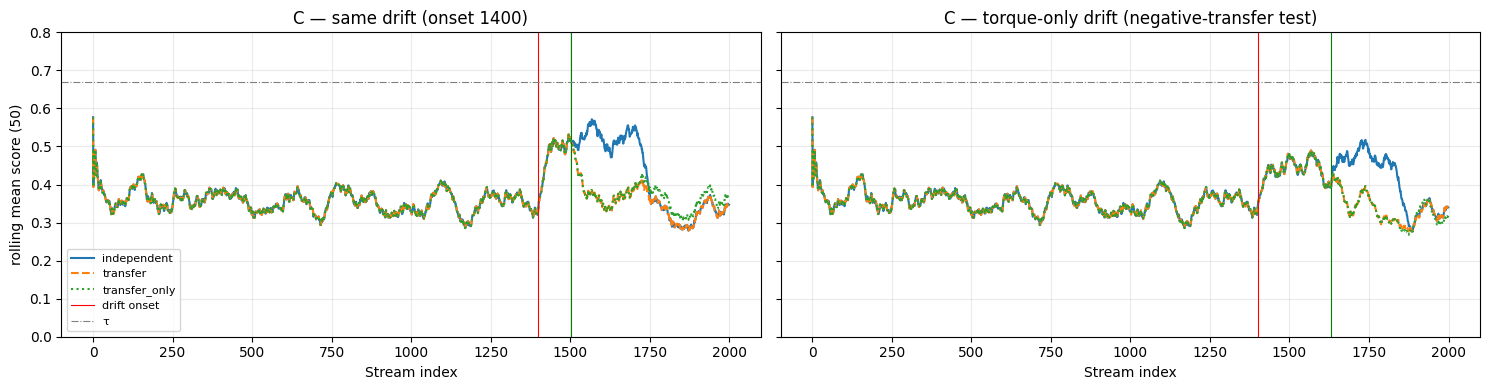

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4), sharey=True)
for ax, (logs_all, title) in zip(axes, [(logs1, "C — same drift (onset 1400)"), (logs3, "C — torque-only drift (negative-transfer test)")]):
    for mode, ls in [("independent", "-"), ("transfer", "--"), ("transfer_only", ":")]:
        m, logs = logs_all[mode]
        ax.plot(logs["C"].score.rolling(50, min_periods=1).mean(), ls=ls, label=mode)
        for e in m.states["C"].events:
            if e["event"] in ("transferred",) and mode == "transfer":
                ax.axvline(e["t"], color="green", lw=.8)
    ax.axvline(1400, color="red", lw=.8, label="drift onset")
    ax.axhline(0.67, color="gray", lw=.8, ls="-.", label="τ")
    ax.set_title(title); ax.set_xlabel("Stream index"); ax.grid(alpha=.25); ax.set_ylim(0, .8)
axes[0].legend(fontsize=8); axes[0].set_ylabel("rolling mean score (50)")
plt.tight_layout(); plt.savefig(ROOT / "figures" / "13_multistream_machine_c.png", dpi=130); plt.show()

In [6]:
pd.concat([res1, res2, res3]).to_csv(ROOT / "results" / "13_multistream.csv", index=False)
print("Phase 13: COMPLETE")

Phase 13: COMPLETE
